#### Importing Libraries

In [68]:
# !pip show torch

In [1]:
import torch
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

12.6
True
1
NVIDIA GeForce RTX 3090


In [3]:
# !pip install transformers

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
import torch

e:\ML\BioActivity\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Data Fetching

In [5]:
df=pd.read_excel("bioactivity_dataset_cleaned.xlsx")
df.head(3)

,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class
0,O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc...,464.522,3.9242,4,6,8.6,active
1,O=C(CCCCCC(C(=O)Nc1ccc2ncccc2c1)C(=O)Nc1ccc2nc...,485.544,4.4323,4,6,9.0,active
2,O=C(/C=C/c1cccc(C(C(=O)Nc2ccccc2)C(=O)Nc2ccccc...,415.449,3.5662,4,4,9.0,active


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6341 entries, 0 to 6340
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   canonical_smiles   6341 non-null   object 
 1   MW                 6341 non-null   float64
 2   LogP               6341 non-null   float64
 3   NumHDonors         6341 non-null   int64  
 4   NumHAcceptors      6341 non-null   int64  
 5   pIC50              6341 non-null   float64
 6   bioactivity_class  6341 non-null   object 
dtypes: float64(3), int64(2), object(2)
memory usage: 346.9+ KB


In [7]:
df.describe(include='all')

,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class
count,6341,6341.000000,6341.000000,6341.000000,6341.000000,6341.000000,6341
unique,5470,NaN,NaN,NaN,NaN,NaN,2
top,O=C(CCCCCCC(=O)Nc1ccccc1)NO,NaN,NaN,NaN,NaN,NaN,active
freq,247,NaN,NaN,NaN,NaN,NaN,5118
mean,NaN,423.154674,3.607172,2.886296,5.617726,6.739003,NaN
std,NaN,120.324203,1.446058,1.146729,2.446312,1.297159,NaN
min,NaN,75.067000,-14.260700,0.000000,0.000000,2.390000,NaN
25%,NaN,345.786000,2.579300,2.000000,4.000000,6.150000,NaN
50%,NaN,405.477000,3.520340,3.000000,5.000000,6.860000,NaN
75%,NaN,484.603000,4.485520,3.000000,7.000000,7.600000,NaN


#### Data Analysis, Log Transformation and Scaling

In [13]:
# fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
# axes = axes.flatten()

# for i, feature in enumerate(numerical_features):
#     axes[i].hist(features_df[feature], bins=30, color='skyblue', alpha=0.7)
#     axes[i].set_title(f'Distribution of {feature}')
#     #plt.hlines(y=0, xmin=features_df[feature].min(), xmax=features_df[feature].max(), color='gray', linewidth=0.8)
#     axes[i].grid(False)
#     axes[i].set_xlabel(feature)
#     axes[i].set_ylabel('Frequency')

# plt.tight_layout()
# plt.show()

In [8]:
numerical_features=['MW', 'LogP', 'NumHDonors', 'NumHAcceptors']

In [9]:
from scipy import stats
for feature in ['MW', 'LogP', 'NumHDonors', 'NumHAcceptors']:
    print(f'Skewness of {feature}: {stats.skew(df[feature])}')
    print(f'Kurtosis of {feature}: {stats.kurtosis(df[feature])}')
    print()

Skewness of MW: 1.7039547520915732
Kurtosis of MW: 8.12811933165514

Skewness of LogP: 0.12756952924714743
Kurtosis of LogP: 4.504990392787611

Skewness of NumHDonors: 1.7011465378764798
Kurtosis of NumHDonors: 20.039103211612883

Skewness of NumHAcceptors: 2.250816099995147
Kurtosis of NumHAcceptors: 11.285003494792763



In [10]:
df.head(2)

,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class
0,O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc...,464.522,3.9242,4,6,8.6,active
1,O=C(CCCCCC(C(=O)Nc1ccc2ncccc2c1)C(=O)Nc1ccc2nc...,485.544,4.4323,4,6,9.0,active


In [11]:
df['bioactivity']=df['bioactivity_class'].map({'active':1, 'inactive':0})
df.head(2)

,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class,bioactivity
0,O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc...,464.522,3.9242,4,6,8.6,active,1
1,O=C(CCCCCC(C(=O)Nc1ccc2ncccc2c1)C(=O)Nc1ccc2nc...,485.544,4.4323,4,6,9.0,active,1


In [12]:
# --- Outlier Detection and Removal (IQR Method) ---
def remove_iqr_outliers(df, features):
    mask = pd.Series([True] * len(df))
    for feature in features:
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        mask &= (df[feature] >= lower_bound) & (df[feature] <= upper_bound)
    return df[mask].reset_index(drop=True)

# Remove outliers from features_df
cleaned_df = remove_iqr_outliers(df, numerical_features)
print(f'After outlier removal: {cleaned_df.shape[0]} rows remain.')

After outlier removal: 5667 rows remain.


In [13]:
print(len(df))
print(len(cleaned_df))

6341
5667


In [14]:
cleaned_df.to_excel("bioactivity_dataset_cleaned_outliers.xlsx", index=False)

In [22]:
cleaned_df.head(3)

,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class,bioactivity
0,O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc...,464.522,3.9242,4,6,8.6,active,1
1,O=C(CCCCCC(C(=O)Nc1ccc2ncccc2c1)C(=O)Nc1ccc2nc...,485.544,4.4323,4,6,9.0,active,1
2,O=C(/C=C/c1cccc(C(C(=O)Nc2ccccc2)C(=O)Nc2ccccc...,415.449,3.5662,4,4,9.0,active,1


In [23]:
features_df=cleaned_df.drop(columns=["bioactivity", "bioactivity_class","pIC50"])
target_df=cleaned_df['bioactivity']

In [14]:
for feature in numerical_features:
    print(f"{feature} Skewness: {features_df[feature].skew()}")
    print(f"{feature} Kurtosis: {features_df[feature].kurtosis()}")

MW Skewness: 0.33649631103108213
MW Kurtosis: -0.14314544805129126
LogP Skewness: 0.211298283825971
LogP Kurtosis: -0.2677861412617246
NumHDonors Skewness: -0.14573377583407354
NumHDonors Kurtosis: -0.5072828635419908
NumHAcceptors Skewness: 0.843903146797742
NumHAcceptors Kurtosis: 0.44255262140283946


In [21]:
# fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
# axes = axes.flatten()
# for i, feature in enumerate(numerical_features):
#     sns.histplot(cleaned_df[feature], kde=True, ax=axes[i])
#     axes[i].set_title(f'Distribution of {feature}')
#     axes[i].grid(False)
#     axes[i].set_xlabel(feature)
#     axes[i].set_ylabel('Frequency')
#     axes[i].legend(title='KDE', labels=['Kernel Density Estimation'])

# plt.tight_layout()
# plt.show()

In [31]:
# features_df['MW']=np.log1p(features_df['MW'])
# features_df['NumHAcceptors']=np.log1p(features_df['NumHAcceptors'])
# features_df['NumHDonors']=np.log1p(features_df['NumHDonors'])

In [24]:
features_df.head(2)

,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors
0,O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc...,464.522,3.9242,4,6
1,O=C(CCCCCC(C(=O)Nc1ccc2ncccc2c1)C(=O)Nc1ccc2nc...,485.544,4.4323,4,6


In [15]:
scaler = StandardScaler()
features_df[numerical_features] = scaler.fit_transform(features_df[numerical_features])


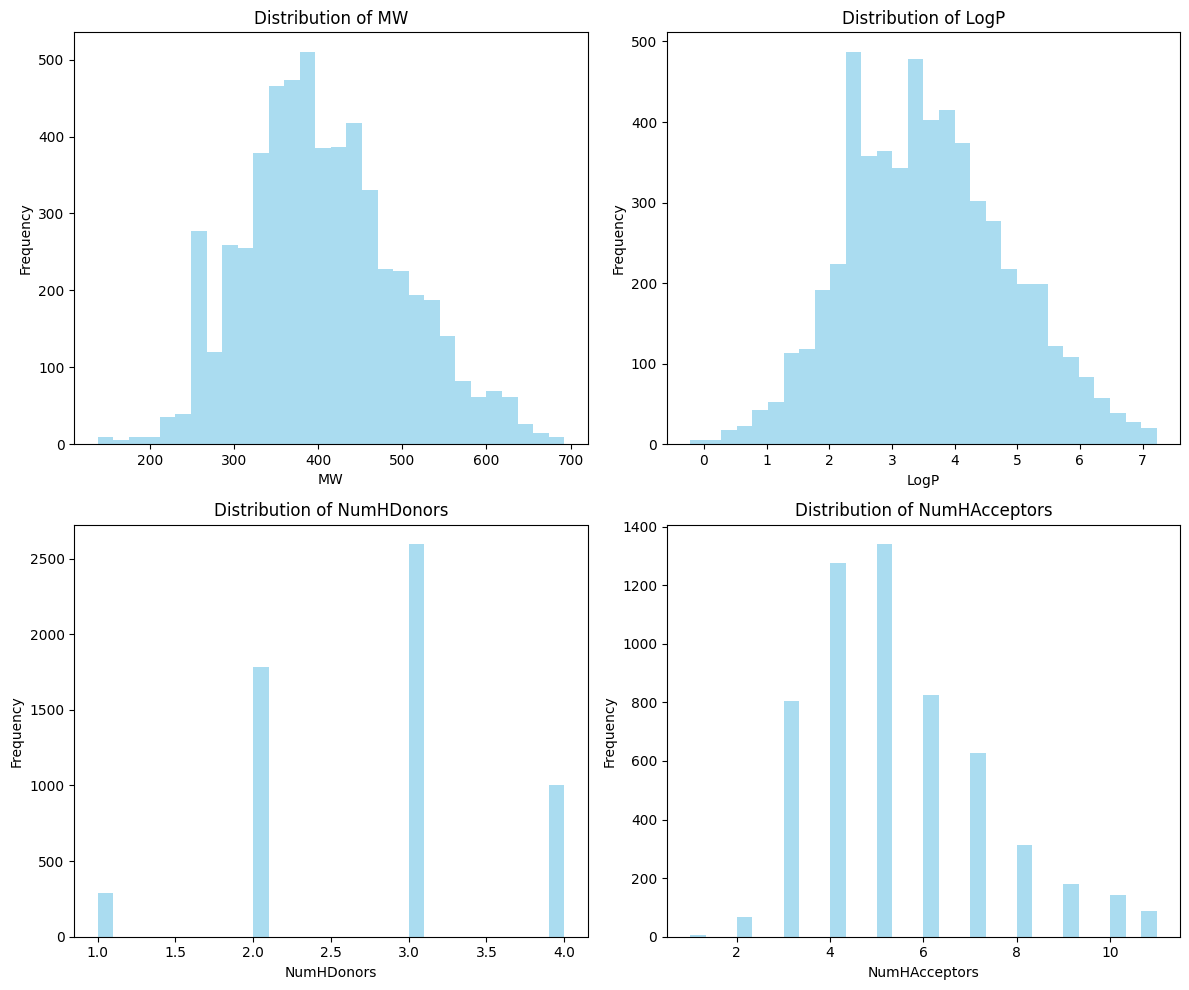

In [25]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    axes[i].hist(features_df[feature], bins=30, color='skyblue', alpha=0.7)
    axes[i].set_title(f'Distribution of {feature}')
    #plt.hlines(y=0, xmin=features_df[feature].min(), xmax=features_df[feature].max(), color='gray', linewidth=0.8)
    axes[i].grid(False)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

#### Train Test Split

In [3]:
import pandas as pd
cleaned_df=pd.read_excel("bioactivity_dataset_cleaned_outliers.xlsx")
cleaned_df.head(2)

,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class,bioactivity
0,O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc...,464.522,3.9242,4,6,8.6,active,1
1,O=C(CCCCCC(C(=O)Nc1ccc2ncccc2c1)C(=O)Nc1ccc2nc...,485.544,4.4323,4,6,9.0,active,1


In [4]:
features_df=cleaned_df.drop(columns=["bioactivity", "bioactivity_class","pIC50"])
target_df=cleaned_df['bioactivity']

In [5]:
numerical_features=['MW', 'LogP', 'NumHDonors', 'NumHAcceptors']
for feature in numerical_features:
    print(f"{feature} Skewness: {features_df[feature].skew()}")
    print(f"{feature} Kurtosis: {features_df[feature].kurtosis()}")

MW Skewness: 0.33649631103108213
MW Kurtosis: -0.14314544805129126
LogP Skewness: 0.211298283825971
LogP Kurtosis: -0.2677861412617246
NumHDonors Skewness: -0.14573377583407354
NumHDonors Kurtosis: -0.5072828635419908
NumHAcceptors Skewness: 0.843903146797742
NumHAcceptors Kurtosis: 0.44255262140283946


In [6]:
scaler = StandardScaler()
features_df[numerical_features] = scaler.fit_transform(features_df[numerical_features])


In [8]:
final_df = pd.concat([features_df, target_df], axis=1)
final_df.head(2)

,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,bioactivity
0,O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc...,0.630845,0.262377,1.550998,0.354379,1
1,O=C(CCCCCC(C(=O)Nc1ccc2ncccc2c1)C(=O)Nc1ccc2nc...,0.858695,0.657022,1.550998,0.354379,1


In [22]:
final_df['canonical_smiles'].iloc[0]

'O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc12)NO'

In [9]:
len(final_df)

5667

In [10]:
train_df, temp_df = train_test_split(final_df, test_size=0.2, random_state=42, stratify=final_df['bioactivity'])  # 60% training data
valid_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['bioactivity']) # 20% validation, 20% test data

# Check the size of each split
print(f"Training set size: {len(train_df)}")
print(f"Validation set size: {len(valid_df)}")
print(f"Test set size: {len(test_df)}")

Training set size: 4533
Validation set size: 567
Test set size: 567


#### Create Dataset

In [11]:
final_df.columns

Index(['canonical_smiles', 'MW', 'LogP', 'NumHDonors', 'NumHAcceptors',
       'bioactivity'],
      dtype='object')

In [12]:
numerical_features

['MW', 'LogP', 'NumHDonors', 'NumHAcceptors']

In [13]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [26]:
# !pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126

In [14]:
print(train_df['bioactivity'].value_counts())
print(valid_df['bioactivity'].value_counts())
print(test_df['bioactivity'].value_counts())

bioactivity
1    3712
0     821
Name: count, dtype: int64
bioactivity
1    465
0    102
Name: count, dtype: int64
bioactivity
1    464
0    103
Name: count, dtype: int64


In [15]:
from torch.utils.data import Dataset
from transformers import AutoTokenizer

# Load pre-trained ChemBERTa tokenizer
tokenizer = AutoTokenizer.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")
#tokenizer = AutoTokenizer.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")

class BioactivityDataset(Dataset):
    def __init__(self, df, numerical_features, tokenizer):
        self.smiles = df['canonical_smiles'].tolist()  # SMILES strings
        self.numerical_features = df[numerical_features].values  # Numerical features
        self.labels = df['bioactivity'].astype(int).values  # Labels (bioactivity class)
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.smiles)

    def __getitem__(self, idx):
        # Tokenize SMILES
        smile = self.smiles[idx]
        smile_tokens = self.tokenizer(smile, padding="max_length", truncation=True, return_tensors="pt", max_length=128)
        
        # Convert numerical features to tensor
        numerical_data = torch.tensor(self.numerical_features[idx], dtype=torch.float32)
        
        # Label
        label = torch.tensor(self.labels[idx], dtype=torch.long)

        # Return tokenized SMILES, numerical features, and label
        return {
            'input_ids': smile_tokens['input_ids'].squeeze(0),  # Remove extra batch dimension
            'attention_mask': smile_tokens['attention_mask'].squeeze(0),  # Attention mask
            'numerical_features': numerical_data,
            'labels': label
        }

# Create dataset for train, validation, and test sets
train_dataset = BioactivityDataset(train_df, numerical_features, tokenizer)
valid_dataset = BioactivityDataset(valid_df, numerical_features, tokenizer)
test_dataset = BioactivityDataset(test_df, numerical_features, tokenizer)


In [28]:
# !pip install huggingface_hub[hf_xet]

In [29]:
#device = torch.device("cpu")

In [30]:
# %pip install 'accelerate>=0.26.0'

#### Model Training

In [26]:
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback, AutoModelForMaskedLM
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, balanced_accuracy_score, roc_auc_score, matthews_corrcoef, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import torch
import torch.nn as nn
import numpy as np
from torch.optim import AdamW

# Focal Loss implementation for better class imbalance handling
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, weight=None):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.weight = weight
    
    def forward(self, inputs, targets):
        ce_loss = torch.nn.functional.cross_entropy(inputs, targets, weight=self.weight, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1-pt)**self.gamma * ce_loss
        return focal_loss.mean()


# Load pre-trained ChemBERTa model with optimized dropout
model = AutoModelForSequenceClassification.from_pretrained(
    "seyonec/ChemBERTa-zinc-base-v1",  # Better performing variant
    num_labels=2, 
    problem_type="single_label_classification",
    hidden_dropout_prob=0.2,  # Reduced from 0.2
    attention_probs_dropout_prob=0.2  # Reduced from 0.2
)

model.to(device)

# Compute class weights for handling imbalanced data
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_df['bioactivity']),
    y=train_df['bioactivity']
)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)


# Enhanced Trainer with Focal Loss and gradual unfreezing
class EnhancedWeightedTrainer(Trainer):
    def __init__(self, use_focal_loss=False, gradual_unfreezing=False, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.use_focal_loss = use_focal_loss
        self.gradual_unfreezing = gradual_unfreezing
        self.focal_loss_fn = FocalLoss(alpha=1, gamma=2, weight=class_weights)
        self.current_epoch = 0
        
        # Initially freeze base model for gradual unfreezing
        if self.gradual_unfreezing:
            self.freeze_base_model()
    
    def freeze_base_model(self):
        """Freeze the base ChemBERTa model parameters"""
        for param in self.model.roberta.parameters():
            param.requires_grad = False
    
    def unfreeze_layers_gradually(self, epoch):
        """Gradually unfreeze layers based on epoch"""
        if epoch >= 3:  # Start unfreezing after 3 epochs
            # Unfreeze all layers
            for param in self.model.roberta.parameters():
                param.requires_grad = True
    
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get('logits')
        
        if self.use_focal_loss:
            loss = self.focal_loss_fn(logits, labels)
        else:
            # Fallback to weighted CrossEntropy with label smoothing
            loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
            loss = loss_fct(logits, labels)
        
        return (loss, outputs) if return_outputs else loss
    
    # def on_epoch_begin(self, args, state, control, **kwargs):
    #     """Handle gradual unfreezing at epoch start"""
    #     if self.gradual_unfreezing:
    #         self.unfreeze_layers_gradually(state.epoch)
    #     super().on_epoch_begin(args, state, control, **kwargs)


# Enhanced metrics computation
def compute_metrics(p):
    predictions, labels = p
    preds = predictions.argmax(axis=-1)
    probs = torch.nn.functional.softmax(torch.tensor(predictions), dim=-1).numpy()
    
    # Basic metrics
    balanced_acc = balanced_accuracy_score(labels, preds)
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    auc = roc_auc_score(labels, probs[:, 1])
    
    # Additional metrics
    mcc = matthews_corrcoef(labels, preds)
    
    # Confusion matrix metrics
    cm = confusion_matrix(labels, preds)
    if cm.shape == (2, 2):  # Binary classification
        tn, fp, fn, tp = cm.ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    else:
        specificity = sensitivity = 0
    
    return {
        "balanced_accuracy": balanced_acc,
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall,
        "auc": auc,
        "matthews_corrcoef": mcc,
        "specificity": specificity,
        "sensitivity": sensitivity
    }


# Optimized training arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=50,  # Reduced from 50
    per_device_train_batch_size=16,  # Increased if GPU memory allows
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=4,  # Adjusted for larger batch size
    warmup_ratio=0.2,  # Reduced from 0.2
    weight_decay=0.05,
    learning_rate=1e-5,  # Reduced from 5e-5
    lr_scheduler_type="linear",  # Changed from cosine
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=3,
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="eval_balanced_accuracy",
    greater_is_better=True,
    fp16=True,
    max_grad_norm=0.5
)

# Custom optimizer with layer-wise learning rate decay
# Simplified optimizer without layer-wise learning rates
def create_simple_optimizer(model):
    no_decay = ["bias", "LayerNorm.weight"]
    optimizer_grouped_parameters = [
        {
            "params": [p for n, p in model.named_parameters() 
                      if not any(nd in n for nd in no_decay) and p.requires_grad],
            "weight_decay": training_args.weight_decay,
        },
        {
            "params": [p for n, p in model.named_parameters() 
                      if any(nd in n for nd in no_decay) and p.requires_grad],
            "weight_decay": 0.0,
        },
    ]
    return AdamW(optimizer_grouped_parameters, lr=training_args.learning_rate)



# Initialize the Enhanced Trainer
trainer = EnhancedWeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(
        early_stopping_patience=5,  # Reduced patience
        early_stopping_threshold=0.001
    )],
    
)


# Train the model
print("Starting enhanced training...")
trainer.train()

# Save the best model
trainer.save_model('./best_enhanced_model')
tokenizer.save_pretrained('./best_enhanced_model')

print("Training completed!")

# Optional: Ensemble prediction function
def ensemble_predict(models, tokenizer, texts, device):
    """
    Ensemble prediction using multiple models
    """
    all_predictions = []
    
    for model in models:
        model.eval()
        predictions = []
        
        with torch.no_grad():
            for text in texts:
                inputs = tokenizer(text, return_tensors="pt", 
                                 padding=True, truncation=True, max_length=512)
                inputs = {k: v.to(device) for k, v in inputs.items()}
                
                outputs = model(**inputs)
                probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
                predictions.append(probs.cpu().numpy())
        
        all_predictions.append(np.array(predictions))
    
    # Average predictions across models
    ensemble_preds = np.mean(all_predictions, axis=0)
    return ensemble_preds

# Example usage for ensemble (train multiple models with different seeds):
# models = []
# for seed in [42, 123, 456]:
#     set_seed(seed)
#     model_seed = AutoModelForSequenceClassification.from_pretrained(...)
#     trainer_seed = EnhancedWeightedTrainer(...)
#     trainer_seed.train()
#     models.append(trainer_seed.model)
# 
# # Use ensemble for final predictions
# ensemble_results = ensemble_predict(models, tokenizer, test_texts, device)


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at seyonec/ChemBERTa-zinc-base-v1 and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\era\AppData\Local\Temp\ipykernel_49380\339233319.py:47: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `EnhancedWeightedTrainer.__init__`. Use `processing_class` instead.
  super().__init__(*args, **kwargs)


Starting enhanced training...


Epoch,Training Loss,Validation Loss,Balanced Accuracy,Accuracy,F1,Precision,Recall,Auc,Matthews Corrcoef,Specificity,Sensitivity
1,0.763100,0.727865,0.571457,0.517647,0.623162,0.864796,0.487069,0.623974,0.110423,0.655844,0.487069
2,0.752200,0.712413,0.593344,0.454118,0.529412,0.900000,0.375000,0.676267,0.151666,0.811688,0.375000
3,0.727200,0.693430,0.648810,0.607059,0.708551,0.902222,0.583333,0.721628,0.229662,0.714286,0.583333
4,0.713500,0.671853,0.652597,0.555294,0.648045,0.920635,0.500000,0.752342,0.236551,0.805195,0.500000
5,0.682100,0.651186,0.673235,0.647059,0.745763,0.909091,0.632184,0.777873,0.269505,0.714286,0.632184
6,0.647800,0.636787,0.683376,0.638824,0.735573,0.918280,0.613506,0.797288,0.283780,0.753247,0.613506
7,0.644300,0.646377,0.746744,0.804706,0.875375,0.916667,0.837644,0.824643,0.437931,0.655844,0.837644
8,0.623500,0.629233,0.755103,0.789412,0.862835,0.924466,0.808908,0.839738,0.436008,0.701299,0.808908
9,0.582500,0.614933,0.764442,0.804706,0.874052,0.926045,0.827586,0.859443,0.459794,0.701299,0.827586
10,0.549600,0.595164,0.771020,0.782353,0.855807,0.935264,0.788793,0.874090,0.451647,0.753247,0.788793


Training completed!


In [27]:
from sklearn.metrics import accuracy_score
# Get predictions on the test set
predictions = trainer.predict(test_dataset)

# Extract the predicted labels (argmax of logits)
predicted_labels = predictions.predictions.argmax(axis=-1)

# Get the true labels
true_labels = predictions.label_ids

# Calculate accuracy
accuracy = balanced_accuracy_score(true_labels, predicted_labels)
print(f"Accuracy: {accuracy}")
print("accuracy another: ", accuracy_score(true_labels, predicted_labels))


Accuracy: 0.83467644263914
accuracy another:  0.882491186839013


In [28]:
from sklearn.metrics import accuracy_score
# Get predictions on the test set
predictions = trainer.predict(train_dataset)

# Extract the predicted labels (argmax of logits)
predicted_labels = predictions.predictions.argmax(axis=-1)

# Get the true labels
true_labels = predictions.label_ids

# Calculate accuracy
accuracy = accuracy_score(true_labels, predicted_labels)
print(f"Accuracy: {accuracy}")


Accuracy: 0.9596570852244075


In [43]:
test_df["bioactivity"].value_counts()

bioactivity
1    464
0    103
Name: count, dtype: int64

#### Optuna based Hyperparameter Tuning

In [16]:
from torch.utils.data import Dataset
from transformers import AutoTokenizer

# Load pre-trained ChemBERTa tokenizer
tokenizer = AutoTokenizer.from_pretrained("DeepChem/ChemBERTa-77M-MLM")
#tokenizer = AutoTokenizer.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")

class BioactivityDataset(Dataset):
    def __init__(self, df, numerical_features, tokenizer):
        self.smiles = df['canonical_smiles'].tolist()  # SMILES strings
        self.numerical_features = df[numerical_features].values  # Numerical features
        self.labels = df['bioactivity'].astype(int).values  # Labels (bioactivity class)
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.smiles)

    def __getitem__(self, idx):
        # Tokenize SMILES
        smile = self.smiles[idx]
        smile_tokens = self.tokenizer(smile, padding="max_length", truncation=True, return_tensors="pt", max_length=128)
        
        # Convert numerical features to tensor
        numerical_data = torch.tensor(self.numerical_features[idx], dtype=torch.float32)
        
        # Label
        label = torch.tensor(self.labels[idx], dtype=torch.long)

        # Return tokenized SMILES, numerical features, and label
        return {
            'input_ids': smile_tokens['input_ids'].squeeze(0),  # Remove extra batch dimension
            'attention_mask': smile_tokens['attention_mask'].squeeze(0),  # Attention mask
            'numerical_features': numerical_data,
            'labels': label
        }

# Create dataset for train, validation, and test sets
train_dataset = BioactivityDataset(train_df, numerical_features, tokenizer)
valid_dataset = BioactivityDataset(valid_df, numerical_features, tokenizer)
test_dataset = BioactivityDataset(test_df, numerical_features, tokenizer)


In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [18]:
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback, AutoModelForMaskedLM
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, balanced_accuracy_score, roc_auc_score, matthews_corrcoef, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import torch
import torch.nn as nn
import numpy as np
from torch.optim import AdamW

# Focal Loss implementation for better class imbalance handling
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, weight=None):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.weight = weight
    
    def forward(self, inputs, targets):
        ce_loss = torch.nn.functional.cross_entropy(inputs, targets, weight=self.weight, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1-pt)**self.gamma * ce_loss
        return focal_loss.mean()
    
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_df['bioactivity']),
    y=train_df['bioactivity']
)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)


# Enhanced Trainer with Focal Loss and gradual unfreezing
class EnhancedWeightedTrainer(Trainer):
    def __init__(self, use_focal_loss=False, gradual_unfreezing=False, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.use_focal_loss = use_focal_loss
        self.gradual_unfreezing = gradual_unfreezing
        self.focal_loss_fn = FocalLoss(alpha=1, gamma=2, weight=class_weights)
        self.current_epoch = 0
        
        # Initially freeze base model for gradual unfreezing
        if self.gradual_unfreezing:
            self.freeze_base_model()
    
    def freeze_base_model(self):
        """Freeze the base ChemBERTa model parameters"""
        for param in self.model.roberta.parameters():
            param.requires_grad = False
    
    def unfreeze_layers_gradually(self, epoch):
        """Gradually unfreeze layers based on epoch"""
        if epoch >= 3:  # Start unfreezing after 3 epochs
            # Unfreeze all layers
            for param in self.model.roberta.parameters():
                param.requires_grad = True
    
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get('logits')
        
        if self.use_focal_loss:
            loss = self.focal_loss_fn(logits, labels)
        else:
            # Fallback to weighted CrossEntropy with label smoothing
            loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
            loss = loss_fct(logits, labels)
        
        return (loss, outputs) if return_outputs else loss
    
    # def on_epoch_begin(self, args, state, control, **kwargs):
    #     """Handle gradual unfreezing at epoch start"""
    #     if self.gradual_unfreezing:
    #         self.unfreeze_layers_gradually(state.epoch)
    #     super().on_epoch_begin(args, state, control, **kwargs)


# Enhanced metrics computation
def compute_metrics(p):
    predictions, labels = p
    preds = predictions.argmax(axis=-1)
    probs = torch.nn.functional.softmax(torch.tensor(predictions), dim=-1).numpy()
    
    # Basic metrics
    balanced_acc = balanced_accuracy_score(labels, preds)
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    auc = roc_auc_score(labels, probs[:, 1])
    
    # Additional metrics
    mcc = matthews_corrcoef(labels, preds)
    
    # Confusion matrix metrics
    cm = confusion_matrix(labels, preds)
    if cm.shape == (2, 2):  # Binary classification
        tn, fp, fn, tp = cm.ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    else:
        specificity = sensitivity = 0
    
    return {
        "balanced_accuracy": balanced_acc,
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall,
        "auc": auc,
        "matthews_corrcoef": mcc,
        "specificity": specificity,
        "sensitivity": sensitivity
    }


In [19]:
import optuna
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback, AutoTokenizer
import torch
import numpy as np

# Define model initialization function for Optuna
def model_init(trial=None):
    if trial is not None:
        hidden_dropout = trial.suggest_float("hidden_dropout_prob", 0.1, 0.5)
        attention_dropout = trial.suggest_float("attention_probs_dropout_prob", 0.1, 0.5)
    else:
        hidden_dropout = 0.2  # default value
        attention_dropout = 0.2  # default value
    return AutoModelForSequenceClassification.from_pretrained(
        "DeepChem/ChemBERTa-77M-MLM",
        num_labels=2,
        problem_type="single_label_classification",
        hidden_dropout_prob=hidden_dropout,
        attention_probs_dropout_prob=attention_dropout
    )

# Define Optuna hyperparameter search space
def optuna_hp_space(trial):
    return {
        "learning_rate": trial.suggest_float("learning_rate", 5e-6, 1e-3, log=True),
        "per_device_train_batch_size": trial.suggest_int("per_device_train_batch_size", 16, 64),
        "weight_decay": trial.suggest_float("weight_decay", 0.01, 0.3),
        "warmup_ratio": trial.suggest_float("warmup_ratio", 0.05, 0.3),
        "num_train_epochs": trial.suggest_int("num_train_epochs", 10, 50),
        "lr_scheduler_type": trial.suggest_categorical("lr_scheduler_type", ["linear", "cosine", "cosine_with_restarts"]),
        "gradient_accumulation_steps": trial.suggest_categorical("gradient_accumulation_steps", [1, 2, 4]),
        "metric_for_best_model": "eval_balanced_accuracy",
        "greater_is_better": True,
        "fp16": True,
        "max_grad_norm": 0.5,
        # Dropout is handled in model_init
    }

# Define objective computation
def compute_objective(metrics):
    return metrics["eval_balanced_accuracy"]

# Training arguments (other hyperparameters will be overwritten by Optuna)
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=20,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=4,
    warmup_ratio=0.2,
    weight_decay=0.05,
    learning_rate=1e-5,
    lr_scheduler_type="linear",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=3,
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="eval_balanced_accuracy",
    greater_is_better=True,
    fp16=True,
    max_grad_norm=0.5
)


# Initialize Trainer
trainer = Trainer(
    model_init=model_init,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]
)

# Run Optuna hyperparameter search
best_run = trainer.hyperparameter_search(
    direction="maximize",
    backend="optuna",
    hp_space=optuna_hp_space,
    n_trials=20,
    compute_objective=compute_objective,
    study_name="chemberta_dropout_study",
)

print(f"Best run: {best_run}")
print(f"Best hyperparameters: {best_run.hyperparameters}")
print(f"Best balanced accuracy: {best_run.objective}")

# Update training_args with best hyperparameters
for key, value in best_run.hyperparameters.items():
    setattr(training_args, key, value)

# Train final model with best hyperparameters and dropout
final_trainer = Trainer(
    model=model_init(),
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]
)

final_trainer.train()
final_trainer.save_model('./saved_model/best_chemberta_model')
tokenizer.save_pretrained('./saved_tokenizer/best_chemberta_model')

C:\Users\era\AppData\Local\Temp\ipykernel_6332\2475759594.py:67: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at DeepChem/ChemBERTa-77M-MLM and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
[I 2025-10-11 21:03:16,732] A new study created in memory with name: chemberta_dropout_study
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 592, 'bos_token_id': 591, 'pad_token_id': 0}.
Some weights of RobertaForS

Epoch,Training Loss,Validation Loss,Balanced Accuracy,Accuracy,F1,Precision,Recall,Auc,Matthews Corrcoef,Specificity,Sensitivity
1,No log,0.463219,0.500000,0.820106,0.901163,0.820106,1.000000,0.659435,0.000000,0.000000,1.000000
2,0.585300,0.433284,0.500000,0.820106,0.901163,0.820106,1.000000,0.749262,0.000000,0.000000,1.000000
3,0.432400,0.403422,0.573055,0.839506,0.909990,0.842491,0.989247,0.808792,0.297167,0.156863,0.989247
4,0.363700,0.411210,0.558349,0.834215,0.907298,0.837887,0.989247,0.818965,0.255663,0.127451,0.989247
5,0.338300,0.371612,0.630803,0.858907,0.919840,0.861163,0.987097,0.826934,0.423226,0.274510,0.987097
6,0.316000,0.359851,0.652087,0.862434,0.921212,0.868571,0.980645,0.834388,0.446113,0.323529,0.980645
7,0.293400,0.366318,0.640607,0.862434,0.921687,0.864407,0.987097,0.833133,0.442961,0.294118,0.987097
8,0.297800,0.361039,0.646584,0.865961,0.923695,0.866290,0.989247,0.840586,0.461791,0.303922,0.989247
9,0.274700,0.357469,0.655313,0.867725,0.924471,0.869318,0.987097,0.841725,0.471428,0.323529,0.987097
10,0.276000,0.367660,0.646584,0.865961,0.923695,0.866290,0.989247,0.842515,0.461791,0.303922,0.989247


[I 2025-10-11 21:04:14,214] Trial 0 finished with value: 0.6504111321948134 and parameters: {'learning_rate': 0.00014375086238204612, 'per_device_train_batch_size': 25, 'weight_decay': 0.16746390850529153, 'warmup_ratio': 0.09409072097832132, 'num_train_epochs': 11, 'lr_scheduler_type': 'linear', 'gradient_accumulation_steps': 4, 'hidden_dropout_prob': 0.24459929353464102, 'attention_probs_dropout_prob': 0.33763189386721393}. Best is trial 0 with value: 0.6504111321948134.
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at DeepChem/ChemBERTa-77M-MLM and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Balanced Accuracy,Accuracy,F1,Precision,Recall,Auc,Matthews Corrcoef,Specificity,Sensitivity
1,0.654100,0.609032,0.500000,0.820106,0.901163,0.820106,1.000000,0.575849,0.000000,0.000000,1.000000
2,0.471500,0.455711,0.500000,0.820106,0.901163,0.820106,1.000000,0.672686,0.000000,0.000000,1.000000
3,0.435100,0.426645,0.500000,0.820106,0.901163,0.820106,1.000000,0.732174,0.000000,0.000000,1.000000
4,0.379500,0.403385,0.563852,0.830688,0.904762,0.839779,0.980645,0.797375,0.243627,0.147059,0.980645
5,0.337300,0.365665,0.652688,0.857143,0.917766,0.869231,0.972043,0.827852,0.425414,0.333333,0.972043
6,0.290700,0.354568,0.664168,0.857143,0.917263,0.873541,0.965591,0.843991,0.433238,0.362745,0.965591
7,0.305800,0.347636,0.667394,0.862434,0.920570,0.874275,0.972043,0.849346,0.453489,0.362745,0.972043
8,0.291200,0.348433,0.667394,0.862434,0.920570,0.874275,0.972043,0.857780,0.453489,0.362745,0.972043
9,0.276400,0.336586,0.687002,0.869489,0.924335,0.881092,0.972043,0.861786,0.489381,0.401961,0.972043
10,0.242700,0.313739,0.740449,0.881834,0.930281,0.901210,0.961290,0.871917,0.558097,0.519608,0.961290


[I 2025-10-11 21:05:21,499] Trial 1 finished with value: 0.7622074636306135 and parameters: {'learning_rate': 4.020101921512134e-05, 'per_device_train_batch_size': 45, 'weight_decay': 0.24535915231542324, 'warmup_ratio': 0.12857068769817193, 'num_train_epochs': 24, 'lr_scheduler_type': 'cosine_with_restarts', 'gradient_accumulation_steps': 1, 'hidden_dropout_prob': 0.23460878468689073, 'attention_probs_dropout_prob': 0.15245352965582581}. Best is trial 1 with value: 0.7622074636306135.
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at DeepChem/ChemBERTa-77M-MLM and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

[I 2025-10-11 21:19:51,966] Trial 19 pruned. 


Best run: BestRun(run_id='15', objective=0.8456672991777356, hyperparameters={'learning_rate': 0.0002199593464124183, 'per_device_train_batch_size': 53, 'weight_decay': 0.12782637154167573, 'warmup_ratio': 0.25557266837075004, 'num_train_epochs': 45, 'lr_scheduler_type': 'cosine', 'gradient_accumulation_steps': 2, 'hidden_dropout_prob': 0.15117484693345362, 'attention_probs_dropout_prob': 0.26671303790771184}, run_summary=None)
Best hyperparameters: {'learning_rate': 0.0002199593464124183, 'per_device_train_batch_size': 53, 'weight_decay': 0.12782637154167573, 'warmup_ratio': 0.25557266837075004, 'num_train_epochs': 45, 'lr_scheduler_type': 'cosine', 'gradient_accumulation_steps': 2, 'hidden_dropout_prob': 0.15117484693345362, 'attention_probs_dropout_prob': 0.26671303790771184}
Best balanced accuracy: 0.8456672991777356


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at DeepChem/ChemBERTa-77M-MLM and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\era\AppData\Local\Temp\ipykernel_6332\2475759594.py:96: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  final_trainer = Trainer(
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 592, 'bos_token_id': 591, 'pad_token_id': 0}.


Epoch,Training Loss,Validation Loss,Balanced Accuracy,Accuracy,F1,Precision,Recall,Auc,Matthews Corrcoef,Specificity,Sensitivity
1,No log,0.621870,0.500000,0.820106,0.901163,0.820106,1.000000,0.569397,0.000000,0.000000,1.000000
2,0.658800,0.465311,0.500000,0.820106,0.901163,0.820106,1.000000,0.661564,0.000000,0.000000,1.000000
3,0.508300,0.431684,0.500000,0.820106,0.901163,0.820106,1.000000,0.748566,0.000000,0.000000,1.000000
4,0.431600,0.396199,0.563251,0.835979,0.908193,0.839416,0.989247,0.814358,0.269996,0.137255,0.989247
5,0.348600,0.346146,0.677198,0.865961,0.922449,0.877670,0.972043,0.838404,0.471639,0.382353,0.972043
6,0.305300,0.335881,0.699557,0.871252,0.924974,0.885827,0.967742,0.859772,0.502072,0.431373,0.967742
7,0.274200,0.314878,0.705534,0.874780,0.927030,0.887795,0.969892,0.868680,0.517111,0.441176,0.969892
8,0.274200,0.319615,0.720240,0.880071,0.929897,0.893069,0.969892,0.882469,0.542141,0.470588,0.969892
9,0.237200,0.298245,0.756230,0.888889,0.934307,0.906883,0.963441,0.884577,0.587709,0.549020,0.963441
10,0.228400,0.307032,0.775364,0.888889,0.933614,0.915289,0.952688,0.898956,0.598414,0.598039,0.952688


('./saved_tokenizer/best_chemberta_model\\tokenizer_config.json',
 './saved_tokenizer/best_chemberta_model\\special_tokens_map.json',
 './saved_tokenizer/best_chemberta_model\\vocab.json',
 './saved_tokenizer/best_chemberta_model\\merges.txt',
 './saved_tokenizer/best_chemberta_model\\added_tokens.json',
 './saved_tokenizer/best_chemberta_model\\tokenizer.json')

In [20]:
from sklearn.metrics import accuracy_score
# Get predictions on the test set
predictions = final_trainer.predict(test_dataset)

# Extract the predicted labels (argmax of logits)
predicted_labels = predictions.predictions.argmax(axis=-1)

# Get the true labels
true_labels = predictions.label_ids

# Calculate accuracy
accuracy = balanced_accuracy_score(true_labels, predicted_labels)
roc_auc = roc_auc_score(true_labels, predicted_labels)
print(f"Accuracy: {accuracy}")
print("accuracy another: ", accuracy_score(true_labels, predicted_labels))
print(f"ROC AUC: {roc_auc}")

Accuracy: 0.8716416973552059
accuracy another:  0.9382716049382716
ROC AUC: 0.8716416973552059


In [21]:
from sklearn.metrics import accuracy_score
# Get predictions on the test set
predictions = final_trainer.predict(train_dataset)

# Extract the predicted labels (argmax of logits)
predicted_labels = predictions.predictions.argmax(axis=-1)

# Get the true labels
true_labels = predictions.label_ids

# Calculate accuracy
accuracy = accuracy_score(true_labels, predicted_labels)
print(f"Accuracy: {accuracy}")


Accuracy: 0.9805868078535186


In [62]:
# sample = train_dataset[0]
# print(sample['labels'], sample['labels'].dtype)

In [42]:
result = final_trainer.evaluate(test_dataset)
print("Evaluation results:", result)

NameError: name 'final_trainer' is not defined

In [64]:
final_trainer.save_model('./saved_model/best_chemberta_model')
tokenizer.save_pretrained('./saved_tokenizer/best_chemberta_model')

('./saved_tokenizer/best_chemberta_model\\tokenizer_config.json',
 './saved_tokenizer/best_chemberta_model\\special_tokens_map.json',
 './saved_tokenizer/best_chemberta_model\\vocab.json',
 './saved_tokenizer/best_chemberta_model\\merges.txt',
 './saved_tokenizer/best_chemberta_model\\added_tokens.json',
 './saved_tokenizer/best_chemberta_model\\tokenizer.json')

In [ ]:
# # Save the model and tokenizer
# model.save_pretrained('./saved_model/ChemBERTa-77M-MTRO')  # Specify the directory where you want to save the model
# tokenizer.save_pretrained('./saved_tokenizer/ChemBERTa-77M-MTRO')  # Save the tokenizer


('./saved_tokenizer/ChemBERTa-77M-MTR\\tokenizer_config.json',
 './saved_tokenizer/ChemBERTa-77M-MTR\\special_tokens_map.json',
 './saved_tokenizer/ChemBERTa-77M-MTR\\vocab.json',
 './saved_tokenizer/ChemBERTa-77M-MTR\\merges.txt',
 './saved_tokenizer/ChemBERTa-77M-MTR\\added_tokens.json',
 './saved_tokenizer/ChemBERTa-77M-MTR\\tokenizer.json')

In [67]:
from sklearn.metrics import accuracy_score
# Get predictions on the test set
predictions = final_trainer.predict(test_dataset)

# Extract the predicted labels (argmax of logits)
predicted_labels = predictions.predictions.argmax(axis=-1)

# Get the true labels
true_labels = predictions.label_ids

# Calculate accuracy
accuracy = accuracy_score(true_labels, predicted_labels)
print(f"Accuracy: {accuracy}")


Accuracy: 0.9022852639873916


In [46]:
valid_df['bioactivity'].value_counts()

bioactivity
1    1024
0     244
Name: count, dtype: int64